In [ ]:
import sys
sys.path.insert(0, '../2d')

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from model import SimpleCNN2DAttentionClassifier
from dataset import OASIS2DDataset


In [ ]:
# CHECKPOINT = '../checkpoints/2d_cv5_32_base/fold_0/checkpoint_epoch_100.pth'
CHECKPOINT = '../checkpoints/2d_cv5_sample/fold_3/best_model.pth'
DATA_DIR   = '../data/processed_oasis_2d_cv5'
FOLD       = 3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
model = SimpleCNN2DAttentionClassifier(
    in_channels=1, num_classes=2, num_slices=80,
    base_channels=8, dropout=0.3, use_content_based=True
)
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE).eval()
print(f"Loaded checkpoint (epoch {ckpt.get('epoch')}, best_val_acc {ckpt.get('best_val_acc', 'N/A')})")


Loaded checkpoint (epoch 73, best_val_acc 0.8428571428571429)


In [23]:
dataset = OASIS2DDataset(DATA_DIR, fold=FOLD, split='val')
loader  = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)

all_labels, all_preds, all_attn = [], [], []

with torch.no_grad():
    for images, labels, _ in loader:
        images = images.to(DEVICE)
        logits, attn = model(images, return_attention=True)
        preds = torch.argmax(logits, dim=1)
        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())
        all_attn.append(attn.cpu())

all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()

tp = np.sum((all_labels == 1) & (all_preds == 1))
fp = np.sum((all_labels == 0) & (all_preds == 1))
fn = np.sum((all_labels == 1) & (all_preds == 0))

precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 score:  {f1:.4f}")

all_attn   = torch.cat(all_attn).numpy()   # (N, 120)

tp_idx = np.where((all_labels == 1) & (all_preds == 1))[0]
tn_idx = np.where((all_labels == 0) & (all_preds == 0))[0]
fp_idx = np.where((all_labels == 0) & (all_preds == 1))[0]  # predicted AD, actually Normal
fn_idx = np.where((all_labels == 1) & (all_preds == 0))[0]  # predicted Normal, actually AD
print(f"TP: {len(tp_idx)}, TN: {len(tn_idx)}, FP: {len(fp_idx)}, FN: {len(fn_idx)}")


Loaded val data for fold 3: 70 subjects
  Shape: (70, 224, 224, 80)
  Normal: 54, Alzheimer: 16
Recall:    0.7500
Precision: 0.6316
F1 score:  0.6857
TP: 12, TN: 47, FP: 7, FN: 4


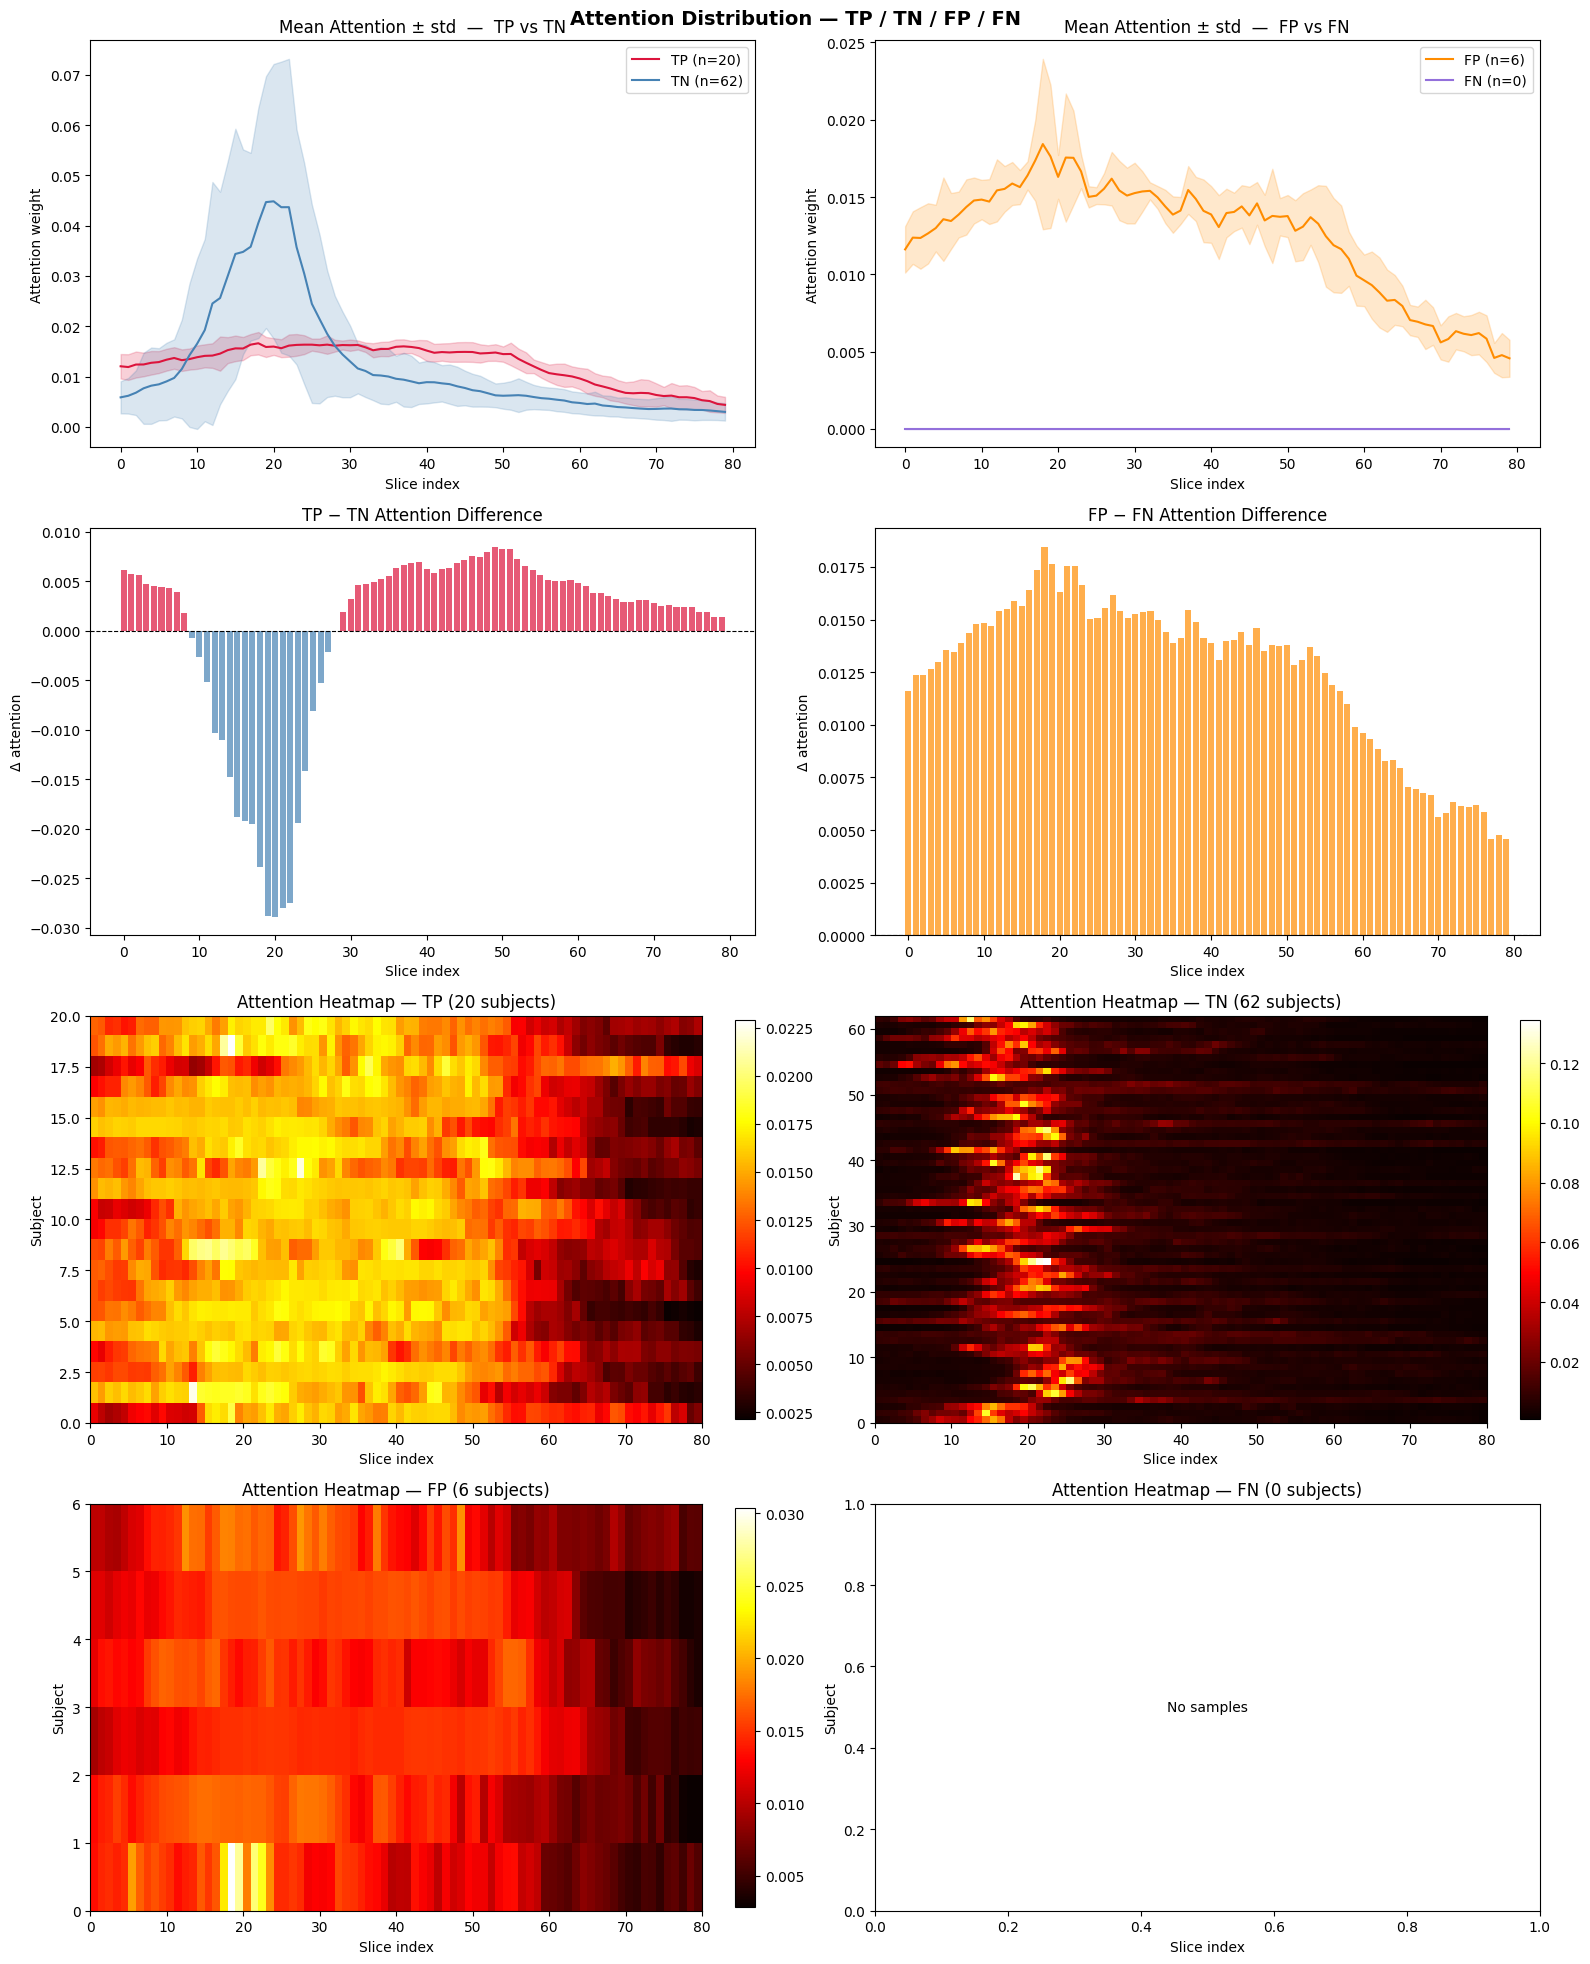

In [41]:
slice_axis = np.arange(80)

groups = {
    'TP': tp_idx, 'TN': tn_idx,
    'FP': fp_idx, 'FN': fn_idx,
}
colors = {'TP': 'crimson', 'TN': 'steelblue', 'FP': 'darkorange', 'FN': 'mediumpurple'}

means = {k: all_attn[v].mean(axis=0) if len(v) else np.zeros(80) for k, v in groups.items()}
stds  = {k: all_attn[v].std(axis=0)  if len(v) else np.zeros(80) for k, v in groups.items()}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Attention Distribution — TP / TN / FP / FN', fontsize=14, fontweight='bold')

# --- Row 0: mean attention TP vs TN ---
ax = axes[0, 0]
for key in ('TP', 'TN'):
    n = len(groups[key])
    ax.plot(slice_axis, means[key], color=colors[key], lw=1.5, label=f'{key} (n={n})')
    ax.fill_between(slice_axis, means[key] - stds[key], means[key] + stds[key],
                    color=colors[key], alpha=0.2)
ax.set_title('Mean Attention ± std  —  TP vs TN')
ax.set_xlabel('Slice index'); ax.set_ylabel('Attention weight'); ax.legend()

# --- Row 0: mean attention FP vs FN ---
ax = axes[0, 1]
for key in ('FP', 'FN'):
    n = len(groups[key])
    ax.plot(slice_axis, means[key], color=colors[key], lw=1.5, label=f'{key} (n={n})')
    ax.fill_between(slice_axis, means[key] - stds[key], means[key] + stds[key],
                    color=colors[key], alpha=0.2)
ax.set_title('Mean Attention ± std  —  FP vs FN')
ax.set_xlabel('Slice index'); ax.set_ylabel('Attention weight'); ax.legend()

# --- Row 1: difference TP − TN ---
ax = axes[1, 0]
diff_tp_tn = means['TP'] - means['TN']
ax.bar(slice_axis, diff_tp_tn,
       color=['crimson' if d > 0 else 'steelblue' for d in diff_tp_tn], alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('TP − TN Attention Difference')
ax.set_xlabel('Slice index'); ax.set_ylabel('Δ attention')

# --- Row 1: difference FP − FN ---
ax = axes[1, 1]
diff_fp_fn = means['FP'] - means['FN']
ax.bar(slice_axis, diff_fp_fn,
       color=['darkorange' if d > 0 else 'mediumpurple' for d in diff_fp_fn], alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('FP − FN Attention Difference')
ax.set_xlabel('Slice index'); ax.set_ylabel('Δ attention')

# --- Rows 2–3: heatmaps for all four groups ---
for row, key in zip([2, 2, 3, 3], ['TP', 'TN', 'FP', 'FN']):
    col = 0 if key in ('TP', 'FP') else 1
    ax = axes[row, col]
    idxs = groups[key]
    if len(idxs):
        im = ax.imshow(all_attn[idxs], aspect='auto', cmap='hot',
                       extent=[0, 80, 0, len(idxs)])
        fig.colorbar(im, ax=ax, fraction=0.03)
    else:
        ax.text(0.5, 0.5, 'No samples', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Attention Heatmap — {key} ({len(idxs)} subjects)')
    ax.set_xlabel('Slice index'); ax.set_ylabel('Subject')

plt.tight_layout()
plt.show()


In [6]:
from ipywidgets import interact

data = np.load('/home/ntq/Projects/longtd/MRI/data/processed_oasis_2d_cv5/fold_0/test.npz')

# 2. List the names of the arrays inside
print(data.files)

['images', 'labels', 'subject_ids']


In [ ]:
images      = data['images']       # (N, 224, 224, 120)
subject_ids = data['subject_ids']  # (N,)

group_indices = {'TP': tp_idx, 'TN': tn_idx, 'FP': fp_idx, 'FN': fn_idx}

def browse(group='TP', subject_idx=0, slice_idx=40):
    idxs = group_indices[group]
    if len(idxs) == 0:
        print(f"No subjects in group {group}.")
        return
    subject_idx = min(subject_idx, len(idxs) - 1)
    global_idx  = idxs[subject_idx]
    img         = images[global_idx][:, :, slice_idx]   # (224, 224)
    attn_val    = all_attn[global_idx, slice_idx]
    label_str   = 'Alzheimer' if all_labels[global_idx] == 1 else 'Normal'
    pred_str    = 'Alzheimer' if all_preds[global_idx]  == 1 else 'Normal'
    sid         = subject_ids[global_idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                             gridspec_kw={'width_ratios': [1, 1.5]})

    # --- MRI slice ---
    axes[0].imshow(img, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title(
        f'[{group}] Subject {subject_idx+1}/{len(idxs)}  •  {sid}\n'
        f'Label: {label_str}  |  Pred: {pred_str}  |  Slice: {slice_idx}',
        fontsize=10
    )

    # --- Attention bar for this subject ---
    ax = axes[1]
    ax.bar(np.arange(80), all_attn[global_idx], color='steelblue', alpha=0.7)
    ax.axvline(slice_idx, color='crimson', lw=1.5, ls='--',
               label=f'slice {slice_idx}  (attn={attn_val:.4f})')
    ax.set_xlabel('Slice index')
    ax.set_ylabel('Attention weight')
    ax.set_title('Attention profile')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

interact(
    browse,
    group     = ['TP', 'TN', 'FP', 'FN'],
    subject_idx = (0, max(len(v) - 1 for v in group_indices.values())),
    slice_idx   = (0, 79),
)


interactive(children=(Dropdown(description='group', options=('TP', 'TN', 'FP', 'FN'), value='TP'), IntSlider(v…

<function __main__.browse(group='TP', subject_idx=0, slice_idx=40)>